## XGBoost on MIMIC IV data

First let us load the data (already preprocessed on tabular_preprocessing.ipynb).

In [8]:
# Importing libraries
import ast
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp


from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack


In [12]:
# Load dataset
df = pd.read_csv("mimiciv_clinical_dataset_tabular_death_visit.csv")

# Count admission categories
admission_counts = df['admission_category'].value_counts()

# Display counts
print("Admission category counts:")
print(admission_counts := df['admission_category'].value_counts())

Admission category counts:
NORMAL       291667
EMERGENCY    254361
Name: admission_category, dtype: int64


In [10]:
df.head(3)

,subject_id,hadm_id,age_at_event,gender,admission_type,admission_category,discharge_location,death_flag,age_at_death,died_during_visit,days_from_last_visit_to_death,days_until_next_visit,icu_admissions,icu_days,num_diagnoses,diagnosis_list,num_procedures,procedure_list,num_medications,medication_list
0,10000032,22595853,52,F,URGENT,EMERGENCY,HOME,1,52.0,0,32.0,50.0,0.0,0.0,8.0,"['Portal hypertension', 'Other ascites', 'Cirr...",1.0,['Percutaneous abdominal drainage'],14.0,"['Furosemide', 'Ipratropium Bromide Neb', 'Pot..."
1,10000032,22841357,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,25.0,0.0,0.0,8.0,['Unspecified viral hepatitis C with hepatic c...,1.0,['Percutaneous abdominal drainage'],15.0,"['Furosemide', 'Rifaximin', 'Sodium Chloride 0..."
2,10000032,29079034,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,11.0,1.0,0.0,13.0,"['Other iatrogenic hypotension', 'Chronic hepa...",0.0,None,24.0,"['Bisacodyl', 'Senna', 'Calcium Carbonate', 'R..."


In [11]:
patients = df['subject_id'].unique()
train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

train_df = df[df['subject_id'].isin(train_patients)].copy()
test_df = df[df['subject_id'].isin(test_patients)].copy()

In [5]:
# Be sure medication_list is a list, e.g.: ['Furosemide', 'Bisacodyl', ...]

def safe_convert(x):
    if pd.isna(x):
        return ''
    elif isinstance(x, list):
        return ' '.join(x)
    elif isinstance(x, str):
        try:
            x_eval = ast.literal_eval(x)
            if isinstance(x_eval, list):
                return ' '.join(x_eval)
            else:
                return ''
        except:
            return ''
    else:
        return ''

# Apply safely to each column:
train_df['med_text'] = train_df['medication_list'].apply(safe_convert)
train_df['diag_text'] = train_df['diagnosis_list'].apply(safe_convert)
train_df['proc_text'] = train_df['procedure_list'].apply(safe_convert)

test_df['med_text'] = test_df['medication_list'].apply(safe_convert)
test_df['diag_text'] = test_df['diagnosis_list'].apply(safe_convert)
test_df['proc_text'] = test_df['procedure_list'].apply(safe_convert)

In [6]:
# FIT CountVectorizer ONLY on training data (ClinicalBench style):
# Define CountVectorizer clearly, limit max features if needed:
med_vectorizer = CountVectorizer(max_features=1000, min_df=10)
diag_vectorizer = CountVectorizer(max_features=1000, min_df=10)
proc_vectorizer = CountVectorizer(max_features=1000, min_df=10)

# Fit on training only:
train_med = med_vectorizer.fit_transform(train_df['med_text'])
train_diag = diag_vectorizer.fit_transform(train_df['diag_text'])
train_proc = proc_vectorizer.fit_transform(train_df['proc_text'])

# Transform test data using fitted training vocabulary:
test_med = med_vectorizer.transform(test_df['med_text'])
test_diag = diag_vectorizer.transform(test_df['diag_text'])
test_proc = proc_vectorizer.transform(test_df['proc_text'])

In [28]:
# Combine sparse matrices horizontally (efficient):
X_train_sparse = sp.hstack([train_med, train_diag, train_proc])
X_test_sparse = sp.hstack([test_med, test_diag, test_proc])

# Convert sparse matrices to arrays if required (optional):
X_train = X_train_sparse.tocsr()
X_test = X_test_sparse.tocsr()

In [ ]:
numeric_features = ['age_at_event', 'icu_admissions', 'icu_days', 'num_diagnoses', 'num_procedures', 'num_medications']
train_numeric = train_df[numeric_features].values
test_numeric = test_df[numeric_features].values

# Final combined features:
X_train_final = hstack([X_train, train_numeric])
X_test_final = hstack([X_test, test_numeric])

In [33]:
# Defining target variable
y_train = (train_df['days_from_last_visit_to_death'] <= 90).astype(int).values
y_test = (test_df['days_from_last_visit_to_death'] <= 90).astype(int).values

In [ ]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_final, y_train)

y_pred_proba = xgb_model.predict_proba(X_test_final)[:, 1]
y_pred = xgb_model.predict(X_test_final)

print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

/root/miniforge3/envs/MIMICIV/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [18:06:59] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1727231492252/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.87      0.96      0.91     87208
           1       0.71      0.43      0.53     22076

    accuracy                           0.85    109284
   macro avg       0.79      0.69      0.72    109284
weighted avg       0.84      0.85      0.83    109284

AUC: 0.872


This approach however has a great limitation: we are not considering the longitudinality of data.
Let us implement here another approach based on Landmark. (TBD)

In [18]:
# Importing libraries
import ast
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp


from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

# Load dataset
df = pd.read_csv("mimiciv_clinical_dataset_tabular_death_visit.csv")

# Count admission categories
admission_counts = df['admission_category'].value_counts()

# Display counts
print("Admission category counts:")
print(admission_counts := df['admission_category'].value_counts())

Admission category counts:
NORMAL       291667
EMERGENCY    254361
Name: admission_category, dtype: int64


In [19]:
df.head(10)

,subject_id,hadm_id,age_at_event,gender,admission_type,admission_category,discharge_location,death_flag,age_at_death,died_during_visit,days_from_last_visit_to_death,days_until_next_visit,icu_admissions,icu_days,num_diagnoses,diagnosis_list,num_procedures,procedure_list,num_medications,medication_list
0,10000032,22595853,52,F,URGENT,EMERGENCY,HOME,1,52.0,0,32.0,50.0,0.0,0.0,8.0,"['Portal hypertension', 'Other ascites', 'Cirr...",1.0,['Percutaneous abdominal drainage'],14.0,"['Furosemide', 'Ipratropium Bromide Neb', 'Pot..."
1,10000032,22841357,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,25.0,0.0,0.0,8.0,['Unspecified viral hepatitis C with hepatic c...,1.0,['Percutaneous abdominal drainage'],15.0,"['Furosemide', 'Rifaximin', 'Sodium Chloride 0..."
2,10000032,29079034,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,11.0,1.0,0.0,13.0,"['Other iatrogenic hypotension', 'Chronic hepa...",0.0,None,24.0,"['Bisacodyl', 'Senna', 'Calcium Carbonate', 'R..."
3,10000032,25742920,52,F,EW EMER.,EMERGENCY,HOSPICE,1,52.0,0,32.0,-1.0,0.0,0.0,10.0,['Chronic hepatitis C without mention of hepat...,1.0,['Percutaneous abdominal drainage'],28.0,"['Sodium Chloride 0.9% Flush', '0.9% Sodium C..."
4,10000068,25022803,19,F,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,-1.0,0.0,0.0,1.0,"['Alcohol abuse, unspecified']",1.0,['Other nonoperative respiratory measurements'],0.0,None
5,10000084,23052089,72,M,EW EMER.,EMERGENCY,HOME HEALTH CARE,1,73.0,0,46.0,32.0,0.0,0.0,6.0,"['Neurocognitive disorder with Lewy bodies', '...",0.0,None,13.0,"['Pramipexole', 'Pravastatin', 'rivastigmine',..."
6,10000084,29888819,72,M,EU OBSERVATION,NORMAL,NaN,1,73.0,0,46.0,-1.0,0.0,0.0,6.0,"['Altered mental status, unspecified', ""Parkin...",0.0,None,0.0,None
7,10000108,27250926,25,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,-1.0,0.0,0.0,2.0,['Cellulitis and abscess of oral soft tissues'...,0.0,None,0.0,None
8,10000117,22927623,55,F,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,672.0,0.0,0.0,9.0,"['Dysphagia, unspecified', 'Other specified sy...",0.0,None,2.0,"['Heparin', 'Sodium Chloride 0.9% Flush']"
9,10000117,27988844,57,F,OBSERVATION ADMIT,NORMAL,HOME HEALTH CARE,0,NaN,0,NaN,-1.0,0.0,0.0,13.0,['Unspecified intracapsular fracture of left f...,1.0,['Reposition Left Upper Femur with Internal Fi...,27.0,"['Iso-Osmotic Dextrose', 'CeFAZolin', 'Vitamin..."


In [ ]:
import ast

def safe_join(x):
    if pd.isna(x) or x in ['[]', '', 'None']:
        return ''
    try:
        x_eval = ast.literal_eval(x)
        if isinstance(x_eval, list):
            return ' '.join(x_eval)
        else:
            return ''
    except:
        return ''

landmark_rows = []

#df = df.sort_values(['subject_id', 'hadm_id']).reset_index(drop=True) # That's not the right ordering!
# the dataset is still ordered, however we should consider a more robust way of doing so.


for patient_id, group in df.groupby('subject_id'):
    group = group.reset_index(drop=True)
    n_visits = group.shape[0]

    for landmark_idx in range(n_visits):
        current_visit = group.iloc[landmark_idx]
        past_visits = group.iloc[:landmark_idx + 1]

        meds_text = ' '.join(past_visits['medication_list'].apply(safe_join))
        diag_text = ' '.join(past_visits['diagnosis_list'].apply(safe_join))
        proc_text = ' '.join(past_visits['procedure_list'].apply(safe_join))

        # Define outcome
        days_to_death = current_visit['days_from_last_visit_to_death']
        death_in_90days = 1 if (not np.isnan(days_to_death) and days_to_death <= 90) else 0

        landmark_rows.append({
            'subject_id': current_visit['subject_id'],
            'landmark_visit': landmark_idx + 1,
            'age_at_landmark': current_visit['age_at_event'],
            'gender': current_visit['gender'],
            'num_total_visits': landmark_idx + 1,
            'days_from_last_visit': current_visit['days_until_next_visit'],
            'death_in_90days': death_in_90days,
            'med_text': meds_text,
            'diag_text': diag_text,
            'proc_text': proc_text
        })

landmark_df = pd.DataFrame(landmark_rows)

In [21]:
landmark_df.head(10)

,subject_id,landmark_visit,age_at_landmark,gender,num_total_visits,days_from_last_visit,death_in_90days,med_text,diag_text,proc_text
0,10000032,1,52,F,1,50.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage
1,10000032,2,52,F,2,25.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...
2,10000032,3,52,F,3,11.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...
3,10000032,4,52,F,4,-1.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...
4,10000068,1,19,F,1,-1.0,0,,"Alcohol abuse, unspecified",Other nonoperative respiratory measurements
5,10000084,1,72,M,1,32.0,1,Pramipexole Pravastatin rivastigmine Senna QUE...,Neurocognitive disorder with Lewy bodies Demen...,
6,10000084,2,72,M,2,-1.0,1,Pramipexole Pravastatin rivastigmine Senna QUE...,Neurocognitive disorder with Lewy bodies Demen...,
7,10000108,1,25,M,1,-1.0,0,,Cellulitis and abscess of oral soft tissues Ot...,
8,10000117,1,55,F,1,672.0,0,Heparin Sodium Chloride 0.9% Flush,"Dysphagia, unspecified Other specified symptom...",
9,10000117,2,57,F,2,-1.0,0,Heparin Sodium Chloride 0.9% Flush Iso-Osmoti...,"Dysphagia, unspecified Other specified symptom...",Reposition Left Upper Femur with Internal Fix...


In [28]:
# Convert gender explicitly into binary numeric values
landmark_df['gender_numeric'] = landmark_df['gender'].map({'F': 0, 'M': 1})
landmark_df.head(5)

,subject_id,landmark_visit,age_at_landmark,gender,num_total_visits,days_from_last_visit,death_in_90days,med_text,diag_text,proc_text,gender_numeric
0,10000032,1,52,F,1,50.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage,0
1,10000032,2,52,F,2,25.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
2,10000032,3,52,F,3,11.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
3,10000032,4,52,F,4,-1.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
4,10000068,1,19,F,1,-1.0,0,,"Alcohol abuse, unspecified",Other nonoperative respiratory measurements,0


### Patient-level Train/Test Split on Landmark dataset

In [31]:
patients = landmark_df['subject_id'].unique()
train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

train_df = landmark_df[landmark_df['subject_id'].isin(train_patients)].copy()
test_df = landmark_df[landmark_df['subject_id'].isin(test_patients)].copy()

### Apply CountVectorizer only on training portion

In [33]:
# Vectorizer for medications
med_vectorizer = CountVectorizer(max_features=1000, min_df=10)
train_med_vec = med_vectorizer.fit_transform(train_df['med_text'])
test_med_vec = med_vectorizer.transform(test_df['med_text'])

# Vectorizer for diagnoses
diag_vectorizer = CountVectorizer(max_features=1000, min_df=10)
train_diag_vec = diag_vectorizer.fit_transform(train_df['diag_text'])
test_diag_vec = diag_vectorizer.transform(test_df['diag_text'])

# Vectorizer for procedures
proc_vectorizer = CountVectorizer(max_features=1000, min_df=10)
train_proc_vec = proc_vectorizer.fit_transform(train_df['proc_text'])
test_proc_vec = proc_vectorizer.transform(test_df['proc_text'])

# numeric features (age, gender, etc.)
numeric_features = ['age_at_landmark',
                    'landmark_visit',
                    'num_total_visits',
                    'days_from_last_visit',
                    'gender_numeric']
X_train_numeric = train_df[numeric_features].values
X_test_numeric = test_df[numeric_features].values

# Combine all features (sparse + numeric)
X_train = hstack([train_med_vec, train_diag_vec, train_proc_vec, X_train_numeric])
X_test = hstack([test_med_vec, test_diag_vec, test_proc_vec, X_test_numeric])

y_train = train_df['death_in_90days'].values
y_test = test_df['death_in_90days'].values

### Train XGBoost model on the LandMark Dataset

In [38]:
model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

In [41]:
print(classification_report(y_test, y_pred))
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91     87208
           1       0.69      0.48      0.57     22076

    accuracy                           0.85    109284
   macro avg       0.78      0.71      0.74    109284
weighted avg       0.84      0.85      0.84    109284

AUC: 0.8864731377572675


### Visualization

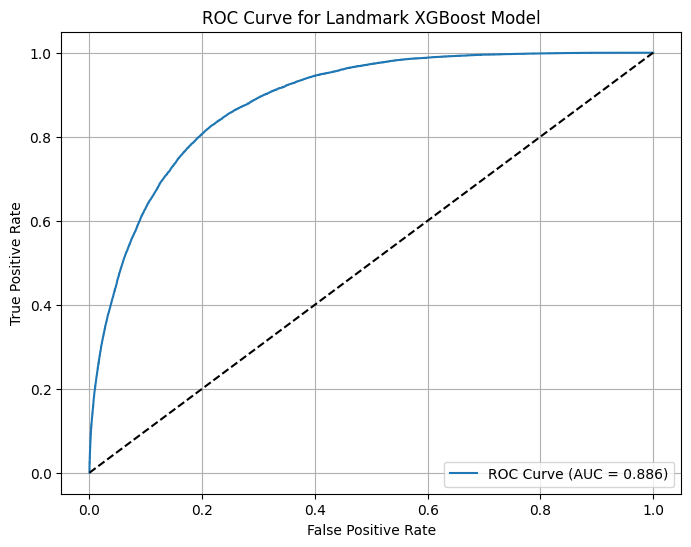

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Landmark XGBoost Model')
plt.legend(loc='lower right')
plt.grid()
plt.show()